# SIFT - Harris
### SIFT - Harris


maximum_filter:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.maximum_filter.html
gaussian_filter:https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.filters.gaussian_filter.html
sobel:https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.sobel.html

matplotlib.patches: https://matplotlib.org/api/patches_api.html

np.where: https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.where.html
np.argwhere: https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.argwhere.html

In [3]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

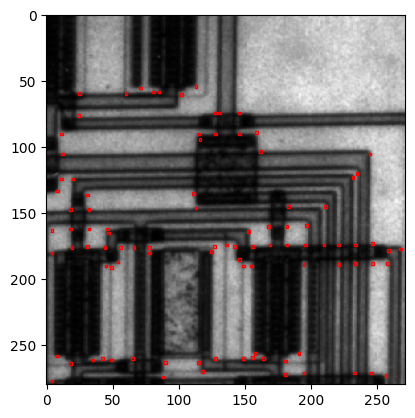

In [2]:
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import gaussian
from scipy.ndimage import maximum_filter, gaussian_filter, sobel
import matplotlib.patches as patches

eps = 1e-6
img = io.imread('circuit.tif').astype(np.float64)

# TODO perform gaussian_filter, this will make the image less noisy not a step in the Harris algorithm
img_smooth = gaussian(img, sigma=1)

# TODO perform sobel to get x-change and y-change
Ix = sobel(img_smooth, axis=1)   
Iy = sobel(img_smooth, axis=0)  

# TODO perform gaussian_filter on x-change * x-change to get sum of Ixx (i.e Sx2)
# TODO perform gaussian_filter on x-change * y-change to get sum of Ixy (i.e Sxy)
# TODO perform gaussian_filter on y-change * y-change to get sum of Iyy (i.e Sy2)
Sx2 = gaussian_filter(Ix * Ix, sigma=1)   # Ixx
Sxy = gaussian_filter(Ix * Iy, sigma=1)   # Ixy
Sy2 = gaussian_filter(Iy * Iy, sigma=1)   # Iyy

# TODO Get R value using the supplied equations (use **2 for power 2)
k = 0.04
detM = Sx2 * Sy2 - Sxy ** 2
traceM = Sx2 + Sy2
R = detM - k * (traceM ** 2)

# TODO Get the R values which are local maximum and above a given threshold. 
R_threshold = 0.1 * R.max()


R_max = maximum_filter(R, size=5)

z = (R == R_max) & (R > R_threshold)

indx = np.argwhere(z == True)

fig, ax = plt.subplots(1)
ax.imshow(img, cmap='gray')

for ind in indx:
    rect = patches.Rectangle((ind[1], ind[0]), 2, 2, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

plt.show()

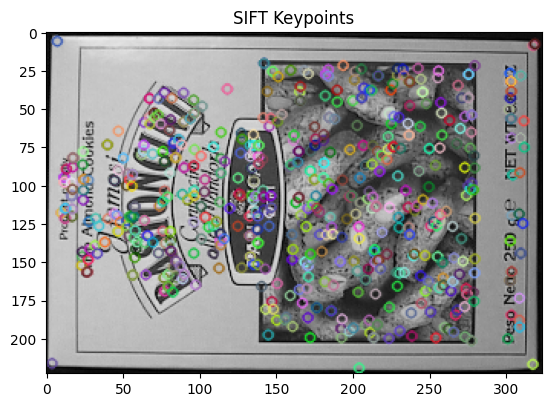

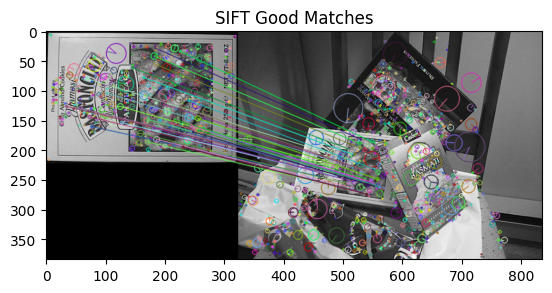

In [4]:



# ## Hint: use the distance in match 
# ## For k=2 knnMatch return the 2 closest matches anyways.
# ## if the distance between the keypoints and its 2 neighbours is close, then the keypoint is ambigious and 
# ## you should neglect it






import numpy as np
import cv2
from matplotlib import pyplot as plt


sift = cv2.SIFT_create()

## TODO: read image box.png and box_in_scene
img1 = cv2.imread(
    r"C:\Users\pc\Documents\GitHub\IP_Requirment_1-2\Lab12\SIFT-Harris-STD\box.png",
    0
)

img2 = cv2.imread(
    r"C:\Users\pc\Documents\GitHub\IP_Requirment_1-2\Lab12\SIFT-Harris-STD\box_in_scene.png",
    0
)



## TODO: find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

## TODO: Construct BFMatcher, Hint use cv2.BFMatcher
img_kp = cv2.drawKeypoints(img1, kp1, None)
plt.imshow(img_kp, cmap='gray')
plt.title("SIFT Keypoints")
plt.show()


# 3) BFMatcher + KNN (k=2)
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

## TODO: Apply ratio test to remove ambigiuous matched (points that has multiple matches)
good_matches = []
ratio = 0.45
for m, n in matches:
    if m.distance < ratio * n.distance:
        good_matches.append([m])

## TODO: Draw the matches features use cv2.drawMatchesKnn with flags =4 
img3 = cv2.drawMatchesKnn(img1, kp1, img2, kp2, good_matches, None, flags=4)

plt.imshow(img3)
plt.title("SIFT Good Matches")
plt.show()
